# CohortX Task 1 — GEPA Prompt Optimization

**What this is.** One self-contained walkthrough of the GEPA experiment: can an automatically
rewritten prompt make our small local model extract the six fields better? It shows the real
code from the `gepa_opt/` package and the real before/after numbers.

**Three moving parts (they never talk to each other directly):**

| role | who | when |
|---|---|---|
| **Student** (does the extraction) | Qwen2.5-1.5B, local via Ollama | dev + ship |
| **Grader** (scores + writes feedback notes) | our metric + the competition scorer | dev only |
| **Reflection** (rewrites the prompt) | Claude Sonnet, Anthropic API | dev only |

The offline competition rule is never broken: Claude is used **only during development** to write a
better prompt. At test time only the local Qwen runs, with that fixed prompt baked in.

**How to run.** Set `RUN_LIVE = False` in the setup cell (default) for a fast demo that shows all
the code and loads cached results. Set it to `True` to actually run Qwen + GEPA (needs Ollama, an
Anthropic key, and the dataset).

In [1]:
# =============================================================================
#  SETUP  —  run this first
# =============================================================================
# RUN_LIVE = False  ->  DEMO MODE: show the real code, load cached results from
#                       results/*.json. Fast, no Ollama or API needed.
# RUN_LIVE = True   ->  actually run Qwen + GEPA end to end
#                       (needs Ollama running, an Anthropic key, and the data).
RUN_LIVE = False

# Google Colab only: uncomment to install deps, then upload the repo (or at
# least its results/ folder) next to this notebook so the cached cells work.
# !pip install dspy-ai pandas matplotlib numpy tqdm python-dotenv

import json
from pathlib import Path
import pandas as pd

RESULTS  = Path("results")          # points at the repo's results/ folder
NOT_SPEC = "Not Specified"

# The six fields we extract from every paper (mirrors data_split.FIELDS).
FIELDS = ["conditions", "study_type", "sex",
          "minimum_age", "maximum_age", "eligibility_criteria"]

print("Mode:", "LIVE (runs Qwen + GEPA)" if RUN_LIVE else "DEMO (cached results)")

Mode: DEMO (cached results)


## 1. The data split

Split the 416 labelled papers into three fixed buckets, seeded so they never change between runs:
- **train**: examples GEPA reflects on
- **val**: examples GEPA scores its candidate prompts against (it *sees* these)
- **holdout**: the honest before/after test set that GEPA *never* sees

Keeping the holdout constant is what makes the before/after comparison fair.

In [2]:
# ---- from gepa_opt/data_split.py -------------------------------------------
# One seeded split of the Train sheet into train / val / holdout, saved to
# results/splits.json so every phase scores on the identical held-out papers.
#   train   = examples GEPA reflects on
#   val     = examples GEPA scores candidate prompts against (it sees these)
#   holdout = the honest before/after test set (GEPA never sees it)
import random

DATA_DIR   = Path.home() / ".cache/kagglehub/competitions/cohort-x-task-1"
DATA_XLSX  = DATA_DIR / "Task_1.xlsx"
NXML_DIR   = DATA_DIR / "PMC_NXML_Archives"
SPLIT_FILE = Path("results/splits.json")
HOLDOUT_IDS_FILE = Path("results/holdout_ids.json")
SEED       = 42


def load_sheet(sheet: str = "Train") -> pd.DataFrame:
    df = pd.read_excel(DATA_XLSX, sheet_name=sheet)
    df["pmcids"] = df["pmcids"].astype(str).str.strip()
    return df


def nxml_path(pid: str) -> Path:
    return NXML_DIR / f"PMC{pid}.nxml"


def gold_dict(row) -> dict:
    """Gold field dict for one row, NaN -> '' (matches evaluate.py)."""
    return {f: ("" if pd.isna(row[f]) else str(row[f])) for f in FIELDS}


def _sync_holdout_ids(splits: dict) -> None:
    """Keep results/holdout_ids.json equal to splits['holdout']."""
    HOLDOUT_IDS_FILE.parent.mkdir(parents=True, exist_ok=True)
    HOLDOUT_IDS_FILE.write_text(json.dumps(splits["holdout"], indent=2))


def get_splits(n_train=60, n_val=40, n_holdout=60, force=False) -> dict:
    if SPLIT_FILE.exists() and not force:
        splits = json.loads(SPLIT_FILE.read_text())
        _sync_holdout_ids(splits)
        return splits
    df = load_sheet("Train")
    pmcids = [p for p in df["pmcids"].tolist() if nxml_path(p).exists()]
    random.Random(SEED).shuffle(pmcids)
    a, b, c = n_train, n_train + n_val, n_train + n_val + n_holdout
    splits = {"train": pmcids[:a], "val": pmcids[a:b], "holdout": pmcids[b:c]}
    SPLIT_FILE.parent.mkdir(parents=True, exist_ok=True)
    SPLIT_FILE.write_text(json.dumps(splits, indent=2))
    _sync_holdout_ids(splits)
    return splits

In [3]:
# Show the actual held-out papers (cached in results/splits.json).
try:
    splits = json.loads((RESULTS / "splits.json").read_text())
    print("split sizes:", {k: len(v) for k, v in splits.items()})
    print("first 5 holdout PMCIDs (GEPA never sees these):", splits["holdout"][:5])
except FileNotFoundError:
    print("results/splits.json not found.")
    print("Set RUN_LIVE=True and call get_splits(), or copy the repo's results/ folder here.")

split sizes: {'train': 60, 'val': 40, 'holdout': 60}
first 5 holdout PMCIDs (GEPA never sees these): ['4538725', '12064614', '12027791', '12394099', '10858376']


## 2. The extractor (what reads a paper)

This wraps the extraction as a DSPy program so GEPA has something to optimize.
- **Signature** = the form: one input (`article_context`) and six output fields.
- **Instruction** = the prompt text on that form. It is seeded with the current hand-written
  baseline prompt, so GEPA's starting point is exactly today's system.
- **Module** = the worker that fills the form. It is crash-proof: if the 1.5B model produces
  broken output, every field falls back to "Not Specified" instead of killing the run.

The prompt text is the *only* thing GEPA is allowed to change. Everything else is fixed.

In [4]:
# ---- from gepa_opt/dspy_program.py -----------------------------------------
# Wrap the extraction as a DSPy program so GEPA can rewrite the instruction.
# These definitions need dspy + the repo, so they live under `if RUN_LIVE`.
# In DEMO mode you read them here; you do not need to run them.
if RUN_LIVE:
    import ast
    import pickle
    import dspy
    from tqdm import tqdm
    from local_llm import predict_ollama
    from common.parser import NXMLParser

    CONTEXT_CACHE = Path("results/contexts.pkl")

    # --- student LM: local Qwen via Ollama, temperature 0 = deterministic ---
    def get_student_lm(model="qwen2.5:1.5b", max_tokens=1024):
        return dspy.LM(f"ollama_chat/{model}", api_base="http://localhost:11434",
                       temperature=0.0, max_tokens=max_tokens)

    def configure_student(model="qwen2.5:1.5b"):
        # JSONAdapter keeps the output shape close to the shipped JSON path.
        dspy.configure(lm=get_student_lm(model), adapter=dspy.JSONAdapter())

    # --- the "form" the model fills in: 1 input, 6 outputs ---
    class ExtractCriteria(dspy.Signature):
        article_context: str = dspy.InputField(
            desc="title / abstract / keywords / relevant sections of a biomedical article")
        conditions: str = dspy.OutputField(desc="primary medical conditions studied")
        study_type: str = dspy.OutputField(desc="INTERVENTIONAL or OBSERVATIONAL")
        sex: str = dspy.OutputField(desc="ALL or MALE or FEMALE")
        minimum_age: str = dspy.OutputField(desc="number followed by Years e.g. 18 Years")
        maximum_age: str = dspy.OutputField(desc="number followed by Years e.g. 65 Years")
        eligibility_criteria: str = dspy.OutputField(desc="full inclusion and exclusion criteria text")

    # Seed the instruction with the shipped prompt so GEPA's "before" == baseline.
    ExtractCriteria = ExtractCriteria.with_instructions(predict_ollama.INSTRUCTION_PROSE)

    class CohortExtractor(dspy.Module):
        def __init__(self):
            super().__init__()
            self.predict = dspy.Predict(ExtractCriteria)

        def forward(self, article_context: str) -> dspy.Prediction:
            try:
                return self.predict(article_context=article_context)
            except Exception:
                # 1.5B models break structured output sometimes — never crash GEPA.
                return dspy.Prediction(**{f: NOT_SPEC for f in FIELDS})

    # --- clean the raw model output into the strings score_row expects ---
    def norm_field(value) -> str:
        if value is None:
            return ""
        if isinstance(value, list):
            return ", ".join(str(v) for v in value)
        s = str(value).strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return ", ".join(str(v) for v in parsed)
            except Exception:
                pass
        return s

    def pred_dict(pred) -> dict:
        return {f: norm_field(getattr(pred, f, "")) for f in FIELDS}

    # --- turn each split into DSPy Examples (context in, gold out) ---
    # Context is built once per paper and cached, so MiniLM filtering runs once.
    def build_contexts(pmcids: list) -> dict:
        cache = pickle.loads(CONTEXT_CACHE.read_bytes()) if CONTEXT_CACHE.exists() else {}
        missing = [p for p in pmcids if p not in cache]
        if missing:
            parser = NXMLParser()
            for pid in tqdm(missing, desc="Building contexts"):
                cache[pid] = predict_ollama.build_article_context(parser.parse(str(nxml_path(pid))))
            CONTEXT_CACHE.parent.mkdir(parents=True, exist_ok=True)
            CONTEXT_CACHE.write_bytes(pickle.dumps(cache))
        return {p: cache[p] for p in pmcids}

    def build_examples(split: str) -> list:
        pmcids = get_splits()[split]
        contexts = build_contexts(pmcids)
        df = load_sheet("Train").set_index("pmcids")
        return [
            dspy.Example(pmcid=pid, article_context=contexts[pid],
                         **gold_dict(df.loc[pid])).with_inputs("article_context")
            for pid in pmcids
        ]

    print("Extractor defined. Seed (baseline) prompt preview:\n")
    print(predict_ollama.INSTRUCTION_PROSE[:600])
else:
    print("[demo] extractor code shown above — not executed. Set RUN_LIVE=True to build it.")

[demo] extractor code shown above — not executed. Set RUN_LIVE=True to build it.


## 3. The grader (GEPA's real lever)

A normal metric returns just a score. GEPA also accepts a **written note**, and that note is the
whole trick: it tells the reflection model exactly *what* went wrong so it can fix the prompt.

The note is targeted:
- **eligibility_criteria** is 50% of the score, so it gets the most detailed feedback (missing
  exclusions, too short, empty).
- **conditions / study_type** get a "here is your answer vs the gold" nudge.
- **ages** get an explicit anti-guessing rule: if the paper does not state an age, output
  "Not Specified", never invent a number.

The demo call below prints the actual note the reflection model would receive on a bad prediction.

In [5]:
# ---- from gepa_opt/dspy_program.py : the GRADER (GEPA's real lever) --------
# A normal metric returns only a number. GEPA also accepts a written note, so we
# tell the reflection model EXACTLY what to fix, per field, weighted toward
# eligibility_criteria (50% of the score) with an explicit anti-guessing rule
# for ages. make_feedback is pure Python, so it runs in demo mode.
def make_feedback(p: dict, g: dict, s: dict) -> str:
    fb = ["Score %.2f (" % s["overall"]
          + ", ".join(f"{k}={s[k]:.2f}" for k in FIELDS) + ")."]

    # eligibility_criteria — 50% of the score, the priority
    if s["eligibility_criteria"] < 0.85:
        pe, ge = p["eligibility_criteria"], g["eligibility_criteria"]
        if not pe.strip() or pe.strip().upper() in ("NOT SPECIFIED", "NULL", "NONE"):
            note = ("you returned nothing — always extract the FULL inclusion AND "
                    "exclusion criteria text from the Participants/Methods/Eligibility section")
        elif "exclu" in ge.lower() and "exclu" not in pe.lower():
            note = "you captured inclusion but MISSED the exclusion criteria the gold lists"
        elif len(pe) < 0.5 * len(ge):
            note = ("your text is far shorter than gold — include every specific criterion "
                    "(diagnoses, lab thresholds, prior treatments), not a summary")
        else:
            note = ("tighten wording and coverage to match the gold's specific inclusion "
                    "AND exclusion items")
        fb.append("eligibility_criteria (HIGHEST weight 0.50): " + note + ".")

    if s["conditions"] < 0.7:
        fb.append(f"conditions: predicted '{p['conditions'][:80]}' vs gold "
                  f"'{g['conditions'][:80]}' — name the SPECIFIC disease(s) studied "
                  "(use title/keywords), not a broad category.")

    if s["study_type"] < 0.7:
        fb.append(f"study_type: predicted '{p['study_type']}' but gold '{g['study_type']}' "
                  "— INTERVENTIONAL only if a treatment/intervention is assigned, else OBSERVATIONAL.")

    for age in ("minimum_age", "maximum_age"):
        if s[age] < 1.0:
            pv, gv = str(p[age]), str(g[age])
            if not gv.strip() or gv.lower() == "nan":
                fb.append(f"{age}: gold has NO age but you output '{pv}'. When the article does "
                          f"not explicitly state the {age.split('_')[0]} age, output "
                          f"'{NOT_SPEC}' — never guess a number.")
            else:
                fb.append(f"{age}: gold is '{gv}' but you output '{pv}'. Only report an age "
                          f"explicitly stated in the text; otherwise '{NOT_SPEC}'.")
    return " ".join(fb)


# DEMO: what the reflection model actually receives on a bad prediction.
demo_p = {"conditions": "cancer", "study_type": "OBSERVATIONAL", "sex": "ALL",
          "minimum_age": "18 Years", "maximum_age": "Not Specified",
          "eligibility_criteria": "Adults with cancer."}
demo_g = {"conditions": "breast cancer", "study_type": "INTERVENTIONAL", "sex": "FEMALE",
          "minimum_age": "18 Years", "maximum_age": "75 Years",
          "eligibility_criteria": "Inclusion: women 18-75 with breast cancer. "
                                  "Exclusion: prior chemotherapy."}
demo_s = {"conditions": 0.40, "study_type": 0.0, "sex": 0.0, "minimum_age": 1.0,
          "maximum_age": 0.0, "eligibility_criteria": 0.30, "overall": 0.31}
print(make_feedback(demo_p, demo_g, demo_s))


# The metric GEPA calls: score number + the feedback note. Needs dspy + score_row.
if RUN_LIVE:
    import dspy
    from common.evaluate import score_row

    def gepa_metric(gold, pred, trace=None, pred_name=None, pred_trace=None):
        p = pred_dict(pred)
        g = {f: norm_field(getattr(gold, f, "")) for f in FIELDS}
        s = score_row(p, g)
        return dspy.Prediction(score=s["overall"], feedback=make_feedback(p, g, s))

Score 0.31 (conditions=0.40, study_type=0.00, sex=0.00, minimum_age=1.00, maximum_age=0.00, eligibility_criteria=0.30). eligibility_criteria (HIGHEST weight 0.50): you captured inclusion but MISSED the exclusion criteria the gold lists. conditions: predicted 'cancer' vs gold 'breast cancer' — name the SPECIFIC disease(s) studied (use title/keywords), not a broad category. study_type: predicted 'OBSERVATIONAL' but gold 'INTERVENTIONAL' — INTERVENTIONAL only if a treatment/intervention is assigned, else OBSERVATIONAL. maximum_age: gold is '75 Years' but you output 'Not Specified'. Only report an age explicitly stated in the text; otherwise 'Not Specified'.


## 4. Baseline (the "before")

Run the real shipped offline path (Qwen with the current hand-written prompt) over the 60 holdout
papers and score it with the competition metric. This is the number GEPA has to beat. In demo mode
we load the cached `results/baseline.json`.

In [6]:
# ---- from gepa_opt/run_eval.py : BASELINE (the "before") -------------------
# Run the real offline path (predict_ollama -> Qwen) over the 60 holdout papers
# and score with the competition metric. This produced results/baseline.json.
if RUN_LIVE:
    from local_llm import predict_ollama
    from common.evaluate import score_row
    from common.parser import NXMLParser
    from tqdm import tqdm

    holdout = get_splits()["holdout"]
    gold_df = load_sheet("Train").set_index("pmcids")
    parser  = NXMLParser()
    scores  = []
    for pid in tqdm(holdout, desc="baseline[holdout]"):
        parsed = parser.parse(str(nxml_path(pid)))
        pred   = predict_ollama.extract(pid, parsed, "qwen2.5:1.5b")
        conds  = pred.get("conditions", [])
        pred["conditions"] = ", ".join(conds) if isinstance(conds, list) else str(conds or "")
        s = score_row({f: pred.get(f, "") for f in FIELDS}, gold_dict(gold_df.loc[pid]))
        scores.append(s)
    sdf = pd.DataFrame(scores)
    baseline_scores = {c: round(float(sdf[c].mean()), 4) for c in sdf.columns}
else:
    try:
        baseline_scores = json.loads((RESULTS / "baseline.json").read_text())["mean_scores"]
    except FileNotFoundError:
        baseline_scores = {}
        print("results/baseline.json not found (add the repo's results/ folder).")

print("BASELINE (before GEPA) — holdout mean scores:")
for f in FIELDS + ["overall"]:
    print(f"  {f:22s}: {baseline_scores.get(f)}")

BASELINE (before GEPA) — holdout mean scores:
  conditions            : 0.2509
  study_type            : 0.7754
  sex                   : 1.0
  minimum_age           : 0.2667
  maximum_age           : 0.4667
  eligibility_criteria  : 0.7807
  overall               : 0.6288


## 5. Run GEPA (dev-time only)

The optimizer loop: GEPA runs the student on a small batch, the grader scores each output and writes
feedback, Claude reads (prompt + outputs + scores + feedback) and proposes a rewritten prompt, and
GEPA keeps the winners on a Pareto frontier. `auto="light"` caps how many scoring calls it spends.
The output is a single new instruction string, saved to `results/optimized_instruction.txt`.

In demo mode we load that saved prompt instead of re-running (which is slow and costs API credits).

In [7]:
# ---- from gepa_opt/optimize_gepa.py : RUN GEPA (dev-time only) --------------
# Student = local Qwen. Reflection = Claude (Anthropic API, dev-time only).
# They never talk directly. GEPA proposes prompts, scores them on val, keeps a
# Pareto set, and Claude rewrites the instruction using the feedback notes.
# Offline rule stays intact: the API is used only here, never at test time.
if RUN_LIVE:
    import os, dspy
    from dotenv import load_dotenv
    from gepa_opt.dspy_program import build_examples   # or use the one defined above
    load_dotenv()
    os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY") or os.getenv("CLAUDE_API_KEY")

    configure_student()                                # student = Qwen + JSONAdapter
    trainset, valset = build_examples("train"), build_examples("val")

    reflection_lm = dspy.LM("anthropic/claude-sonnet-4-6", temperature=1.0, max_tokens=32000)
    optimizer = dspy.GEPA(
        metric=gepa_metric,
        reflection_lm=reflection_lm,
        num_threads=2,
        reflection_minibatch_size=3,
        track_stats=True,
        seed=0,
        auto="light",                                  # small budget of scoring calls
    )
    optimized = optimizer.compile(CohortExtractor(), trainset=trainset, valset=valset)

    optimized_instruction = optimized.predict.signature.instructions
    Path("results/optimized_instruction.txt").write_text(optimized_instruction)
else:
    try:
        optimized_instruction = (RESULTS / "optimized_instruction.txt").read_text().strip()
    except FileNotFoundError:
        optimized_instruction = ""
        print("results/optimized_instruction.txt not found (add the repo's results/ folder).")

print("GEPA-optimized instruction (the prompt Claude rewrote):\n")
print(optimized_instruction[:1200])

GEPA-optimized instruction (the prompt Claude rewrote):

You are a biomedical information extraction system. Read the following article and extract the requested fields according to the rules below.

---

## Field-by-Field Instructions

### conditions
- List the specific human disease(s) or medical condition(s) that are the PRIMARY focus of the study.
- Use the title, abstract, and keywords to identify them.
- Always return a non-empty list with at least one condition.
- Use standard clinical/medical terminology (e.g., "Stroke, Acute" rather than "Wake-up Stroke"; "follicular lymphoma" rather than "low-tumor-burden follicular lymphoma").
- Do NOT use overly narrow sub-classifications as the condition name if a standard disease name exists.
- Do NOT use broad categories when a specific disease is named.

### study_type
- Choose ONE of: INTERVENTIONAL or OBSERVATIONAL.
- Use INTERVENTIONAL only if the study actively assigns participants to receive a treatment, drug, procedure, or interve

## 6. Transfer check (the number that counts)

Important subtlety: GEPA scored prompts while DSPy's JSON wrapper formatted the output. The shipped
path uses a *different* wrapper. So a good GEPA val score is only a proxy. We paste the optimized
prompt back into the real offline path and re-score it on the **same 60 holdout papers**.

Rule: if this does not beat baseline, GEPA did not help, whatever its internal score said. In demo
mode we load the cached `results/transfer_check.json`.

In [8]:
# ---- from gepa_opt/check_transfer.py : TRANSFER CHECK (the number that counts)
# GEPA scored prompts under DSPy's JSON wrapper. The shipped path uses a
# different wrapper, so we re-score the optimized prompt on the REAL offline
# path, over the SAME 60 holdout papers. If it does not beat baseline, GEPA
# did not help — no matter what its internal val score said.
if RUN_LIVE:
    from local_llm import predict_ollama as po
    from common.evaluate import score_row
    from common.parser import NXMLParser
    from tqdm import tqdm

    opt = (RESULTS / "optimized_instruction.txt").read_text().strip()
    po.INSTRUCTION_PROSE = opt
    po.INSTRUCTION = f"{opt}\n\n{po.OUTPUT_SCHEMA}"     # keep the offline output scaffold

    holdout = [str(x) for x in json.loads((RESULTS / "holdout_ids.json").read_text())]
    gold_df = load_sheet("Train").set_index("pmcids")
    parser  = NXMLParser()
    scores  = []
    for pid in tqdm(holdout, desc="transfer[holdout]"):
        parsed = parser.parse(str(nxml_path(pid)))
        pred   = po.extract(pid, parsed, "qwen2.5:1.5b")
        conds  = pred.get("conditions", [])
        pred["conditions"] = ", ".join(conds) if isinstance(conds, list) else str(conds or "")
        s = score_row({f: pred.get(f, "") for f in FIELDS}, gold_dict(gold_df.loc[pid]))
        scores.append(s)
    sdf = pd.DataFrame(scores)
    optimized_scores = {c: round(float(sdf[c].mean()), 4) for c in sdf.columns}
else:
    try:
        optimized_scores = json.loads((RESULTS / "transfer_check.json").read_text())["mean_scores"]
    except FileNotFoundError:
        optimized_scores = {}
        print("results/transfer_check.json not found (add the repo's results/ folder).")

print("OPTIMIZED on the real offline path — holdout mean scores:")
for f in FIELDS + ["overall"]:
    print(f"  {f:22s}: {optimized_scores.get(f)}")

OPTIMIZED on the real offline path — holdout mean scores:
  conditions            : 0.5504
  study_type            : 0.8799
  sex                   : 1.0
  minimum_age           : 0.05
  maximum_age           : 0.4833
  eligibility_criteria  : 0.8223
  overall               : 0.685


## 7. Before vs after

Baseline vs the optimized prompt on the real offline path, same papers, same metric. The table shows
every field plus overall; the chart shows the per-field bars. This is the headline result to present
alongside the Notion report.

field                   baseline  optimized    delta
conditions                0.2509     0.5504  +0.2995
study_type                0.7754     0.8799  +0.1045
sex                       1.0000     1.0000  +0.0000
minimum_age               0.2667     0.0500  -0.2167
maximum_age               0.4667     0.4833  +0.0166
eligibility_criteria      0.7807     0.8223  +0.0416
overall                   0.6288     0.6850  +0.0562


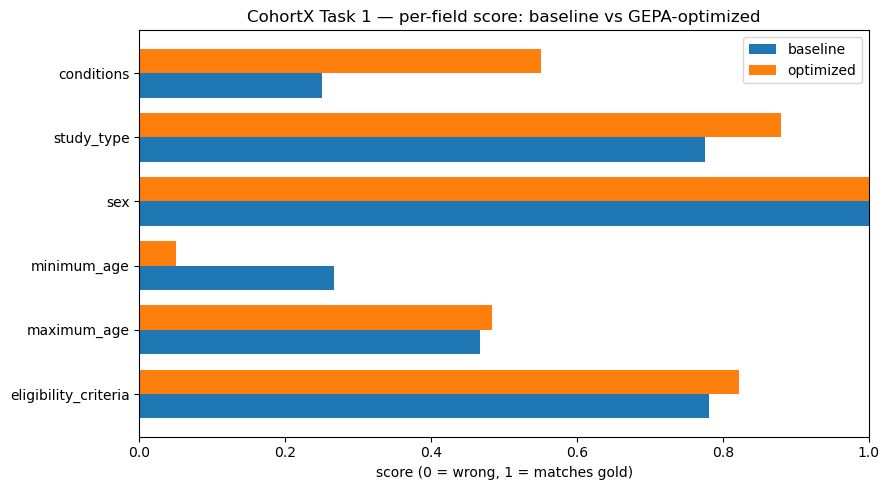

In [9]:
# ---- BEFORE vs AFTER : table + chart ---------------------------------------
import numpy as np
import matplotlib.pyplot as plt

try:
    base = json.loads((RESULTS / "baseline.json").read_text())["mean_scores"]
    opt  = json.loads((RESULTS / "transfer_check.json").read_text())["mean_scores"]

    order = ["conditions", "study_type", "sex", "minimum_age",
             "maximum_age", "eligibility_criteria", "overall"]
    print(f"{'field':22s}{'baseline':>10}{'optimized':>11}{'delta':>9}")
    for f in order:
        b, o = float(base.get(f, 0)), float(opt.get(f, 0))
        print(f"{f:22s}{b:10.4f}{o:11.4f}{o - b:+9.4f}")

    fields = order[:-1]                       # per-field bars (overall shown in the table)
    y, hgt = np.arange(len(fields)), 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(y + hgt / 2, [base.get(f, 0) for f in fields], height=hgt, label="baseline")
    ax.barh(y - hgt / 2, [opt.get(f, 0)  for f in fields], height=hgt, label="optimized")
    ax.set_yticks(y); ax.set_yticklabels(fields); ax.invert_yaxis()
    ax.set_xlim(0, 1); ax.set_xlabel("score (0 = wrong, 1 = matches gold)")
    ax.set_title("CohortX Task 1 — per-field score: baseline vs GEPA-optimized")
    ax.legend(loc="upper right"); plt.tight_layout(); plt.show()
except FileNotFoundError:
    print("Need results/baseline.json and results/transfer_check.json to draw this.")
    print("Copy the repo's results/ folder next to the notebook (or run with RUN_LIVE=True).")

## Where each section lives in the repo

| notebook section | source file |
|---|---|
| 1. data split | `gepa_opt/data_split.py` |
| 2. extractor | `gepa_opt/dspy_program.py` |
| 3. grader | `gepa_opt/dspy_program.py` (`make_feedback`, `gepa_metric`) |
| 4. baseline | `gepa_opt/run_eval.py` |
| 5. run GEPA | `gepa_opt/optimize_gepa.py` |
| 6. transfer check | `gepa_opt/check_transfer.py` |

Not shown here (qualitative, optional): `gepa_opt/scenario_test.py` prints per-paper
prediction-vs-gold so you can eyeball behaviour (did it stop guessing ages? did it catch exclusions?).

**To run for real:** `RUN_LIVE = True`, make sure Ollama is serving `qwen2.5:1.5b`, put your key in
`.env`, and have the dataset cached where `data_split.py` expects it.